In [2]:
# SQL Engine
import sqlalchemy as sa

db_path = r"C:\Users\rober\Documents\Python\bitcoin_gold_analysis\data\bitcoin_gold_database.db"
engine = sa.create_engine(f'sqlite:///{db_path}')

inspector = sa.inspect(engine)
print(f"Tables found: {inspector.get_table_names()}")

Tables found: ['macro_data', 'market_data_filled', 'market_data_sycned']


In [3]:
import pandas as pd

# Pull Daily Market Data - Using Sycned 
df_daily = pd.read_sql(
    "SELECT Date, BTC, DXY, Gold, SP500, Yield_10Y, VIX FROM market_data_sycned", engine)

df_daily['Date'] = pd.to_datetime(df_daily['Date'])
df_daily.sort_values('Date', inplace=True)

df_daily.head()

,Date,BTC,DXY,Gold,SP500,Yield_10Y,VIX
0,2016-01-04,433.091003,98.870003,1075.099976,2012.660034,2.245,20.700001
1,2016-01-05,431.959991,99.400002,1078.400024,2016.709961,2.248,19.340000
2,2016-01-06,429.105011,99.180000,1091.900024,1990.260010,2.177,20.590000
3,2016-01-07,458.048004,98.220001,1107.699951,1943.089966,2.153,24.990000
4,2016-01-08,453.230011,98.540001,1097.800049,1922.030029,2.130,27.010000


In [4]:
# Pull Macro Data
df_macro = pd.read_sql(
    "SELECT Date, CPI_YoY, M2_YoY FROM macro_data", engine)

df_macro['Date'] = pd.to_datetime(df_macro['Date'])
df_macro.sort_values('Date', inplace=True)

df_macro.tail()

,Date,CPI_YoY,M2_YoY
115,2025-08-01,0.029392,0.044263
116,2025-09-01,0.030227,0.044897
117,2025-10-01,0.028950,0.046447
118,2025-11-01,0.027120,0.042704
119,2025-12-01,0.026533,0.046045


In [5]:
# Ensure df_daily Date is the index and datetime format
if 'Date' in df_daily.columns:
    df_daily['Date'] = pd.to_datetime(df_daily['Date'])
    df_daily.set_index('Date', inplace=True)
elif not isinstance(df_daily.index, pd.DatetimeIndex):
    df_daily.index = pd.to_datetime(df_daily.index)

# Resample Daily to Monthly (last price of each month)
monthly_market = df_daily.resample('ME').last()

# Calculate YoY % Change
market_yoy = monthly_market.pct_change(12)

# Prep Dates for df_macro
if 'Date' in df_macro.columns:
    df_macro['Date'] = pd.to_datetime(df_macro['Date'])
    df_macro.set_index('Date', inplace=True)

# Snap to Period (align 01-01 with 01-31)
if not isinstance(market_yoy.index, pd.PeriodIndex):
    market_yoy.index = market_yoy.index.to_period('M')
if not isinstance(df_macro.index, pd.PeriodIndex):
    df_macro.index = df_macro.index.to_period('M')

# Combine Market and Macro 
combined_monthly = pd.concat([
    market_yoy, 
    df_macro[['CPI_YoY', 'M2_YoY']]
], axis=1).dropna()

combined_monthly.head()

,BTC,DXY,Gold,SP500,Yield_10Y,VIX,CPI_YoY,M2_YoY
Date,,,,,,,,
2017-01,1.557232,-0.001004,0.082587,0.174530,0.269291,-0.406436,0.025104,0.063556
2017-02,1.695860,0.029630,0.015155,0.223270,0.355172,-0.371290,0.028104,0.062754
2017-03,1.571911,0.060894,0.010614,0.147096,0.341545,-0.113262,0.024412,0.063332
2017-04,1.892746,0.064138,-0.017918,0.154409,0.254535,-0.310828,0.021762,0.061129
2017-05,3.302729,0.010741,0.047086,0.150147,0.197383,-0.266385,0.018563,0.059634


In [6]:
# Granger Causality Test
from statsmodels.tsa.stattools import grangercausalitytests

# Testing BTC vs M2
M2_test_btc = combined_monthly[['BTC', 'M2_YoY']] 
gc_M2 = grangercausalitytests(M2_test_btc, maxlag=6)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.9851  , p=0.3233  , df_denom=104, df_num=1
ssr based chi2 test:   chi2=1.0135  , p=0.3141  , df=1
likelihood ratio test: chi2=1.0087  , p=0.3152  , df=1
parameter F test:         F=0.9851  , p=0.3233  , df_denom=104, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=1.0094  , p=0.3681  , df_denom=101, df_num=2
ssr based chi2 test:   chi2=2.1188  , p=0.3467  , df=2
likelihood ratio test: chi2=2.0979  , p=0.3503  , df=2
parameter F test:         F=1.0094  , p=0.3681  , df_denom=101, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=1.0767  , p=0.3627  , df_denom=98, df_num=3
ssr based chi2 test:   chi2=3.4607  , p=0.3259  , df=3
likelihood ratio test: chi2=3.4049  , p=0.3333  , df=3
parameter F test:         F=1.0767  , p=0.3627  , df_denom=98, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=0.9760  , p=0.4245  , 

In [7]:
# Testing Gold vs M2
M2_test_gold = combined_monthly[['Gold', 'M2_YoY']] 
gc_M2 = grangercausalitytests(M2_test_gold, maxlag=6)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=3.8692  , p=0.0518  , df_denom=104, df_num=1
ssr based chi2 test:   chi2=3.9809  , p=0.0460  , df=1
likelihood ratio test: chi2=3.9086  , p=0.0480  , df=1
parameter F test:         F=3.8692  , p=0.0518  , df_denom=104, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=2.3663  , p=0.0990  , df_denom=101, df_num=2
ssr based chi2 test:   chi2=4.9670  , p=0.0835  , df=2
likelihood ratio test: chi2=4.8541  , p=0.0883  , df=2
parameter F test:         F=2.3663  , p=0.0990  , df_denom=101, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=2.6675  , p=0.0519  , df_denom=98, df_num=3
ssr based chi2 test:   chi2=8.5741  , p=0.0355  , df=3
likelihood ratio test: chi2=8.2419  , p=0.0413  , df=3
parameter F test:         F=2.6675  , p=0.0519  , df_denom=98, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=2.3485  , p=0.0598  , 

In [8]:
# Testing BTC vs DXY
DXY_test_btc = combined_monthly[['BTC', 'DXY']] 
gc_DXY = grangercausalitytests(DXY_test_btc, maxlag=6)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.5229  , p=0.4712  , df_denom=104, df_num=1
ssr based chi2 test:   chi2=0.5379  , p=0.4633  , df=1
likelihood ratio test: chi2=0.5366  , p=0.4638  , df=1
parameter F test:         F=0.5229  , p=0.4712  , df_denom=104, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.4962  , p=0.6103  , df_denom=101, df_num=2
ssr based chi2 test:   chi2=1.0415  , p=0.5941  , df=2
likelihood ratio test: chi2=1.0364  , p=0.5956  , df=2
parameter F test:         F=0.4962  , p=0.6103  , df_denom=101, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.2876  , p=0.8342  , df_denom=98, df_num=3
ssr based chi2 test:   chi2=0.9245  , p=0.8195  , df=3
likelihood ratio test: chi2=0.9205  , p=0.8205  , df=3
parameter F test:         F=0.2876  , p=0.8342  , df_denom=98, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=0.3449  , p=0.8469  , 

In [9]:
# Testing Gold vs DXY
DXY_test_gold = combined_monthly[['Gold', 'DXY']] 
gc_DXY = grangercausalitytests(DXY_test_gold, maxlag=6)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=2.1887  , p=0.1421  , df_denom=104, df_num=1
ssr based chi2 test:   chi2=2.2518  , p=0.1335  , df=1
likelihood ratio test: chi2=2.2284  , p=0.1355  , df=1
parameter F test:         F=2.1887  , p=0.1421  , df_denom=104, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=2.1886  , p=0.1174  , df_denom=101, df_num=2
ssr based chi2 test:   chi2=4.5940  , p=0.1006  , df=2
likelihood ratio test: chi2=4.4972  , p=0.1055  , df=2
parameter F test:         F=2.1886  , p=0.1174  , df_denom=101, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=1.6313  , p=0.1871  , df_denom=98, df_num=3
ssr based chi2 test:   chi2=5.2434  , p=0.1548  , df=3
likelihood ratio test: chi2=5.1166  , p=0.1635  , df=3
parameter F test:         F=1.6313  , p=0.1871  , df_denom=98, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=1.7106  , p=0.1540  , 

In [11]:
# Testing Bitcoin vs 10Y
DXY_test_gold = combined_monthly[['BTC', 'Yield_10Y']] 
gc_DXY = grangercausalitytests(DXY_test_gold, maxlag=6)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.8382  , p=0.3620  , df_denom=104, df_num=1
ssr based chi2 test:   chi2=0.8624  , p=0.3531  , df=1
likelihood ratio test: chi2=0.8589  , p=0.3540  , df=1
parameter F test:         F=0.8382  , p=0.3620  , df_denom=104, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.3344  , p=0.7165  , df_denom=101, df_num=2
ssr based chi2 test:   chi2=0.7020  , p=0.7040  , df=2
likelihood ratio test: chi2=0.6997  , p=0.7048  , df=2
parameter F test:         F=0.3344  , p=0.7165  , df_denom=101, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.4132  , p=0.7439  , df_denom=98, df_num=3
ssr based chi2 test:   chi2=1.3282  , p=0.7224  , df=3
likelihood ratio test: chi2=1.3199  , p=0.7244  , df=3
parameter F test:         F=0.4132  , p=0.7439  , df_denom=98, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=0.5743  , p=0.6819  , 

In [12]:
# Testing Gold vs 10Y
DXY_test_gold = combined_monthly[['Gold', 'Yield_10Y']] 
gc_DXY = grangercausalitytests(DXY_test_gold, maxlag=6)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.2819  , p=0.5966  , df_denom=104, df_num=1
ssr based chi2 test:   chi2=0.2900  , p=0.5902  , df=1
likelihood ratio test: chi2=0.2896  , p=0.5905  , df=1
parameter F test:         F=0.2819  , p=0.5966  , df_denom=104, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.5428  , p=0.5828  , df_denom=101, df_num=2
ssr based chi2 test:   chi2=1.1394  , p=0.5657  , df=2
likelihood ratio test: chi2=1.1333  , p=0.5674  , df=2
parameter F test:         F=0.5428  , p=0.5828  , df_denom=101, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.3863  , p=0.7631  , df_denom=98, df_num=3
ssr based chi2 test:   chi2=1.2417  , p=0.7430  , df=3
likelihood ratio test: chi2=1.2344  , p=0.7448  , df=3
parameter F test:         F=0.3863  , p=0.7631  , df_denom=98, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=0.5778  , p=0.6794  , 

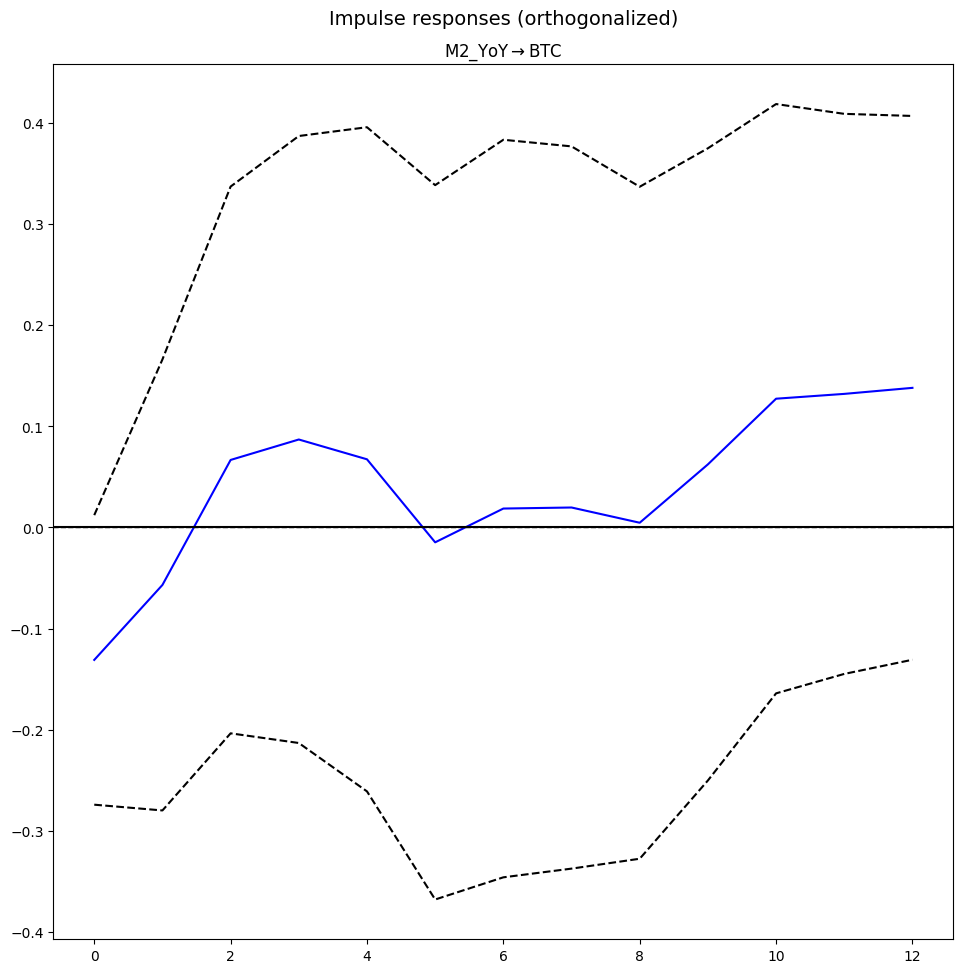

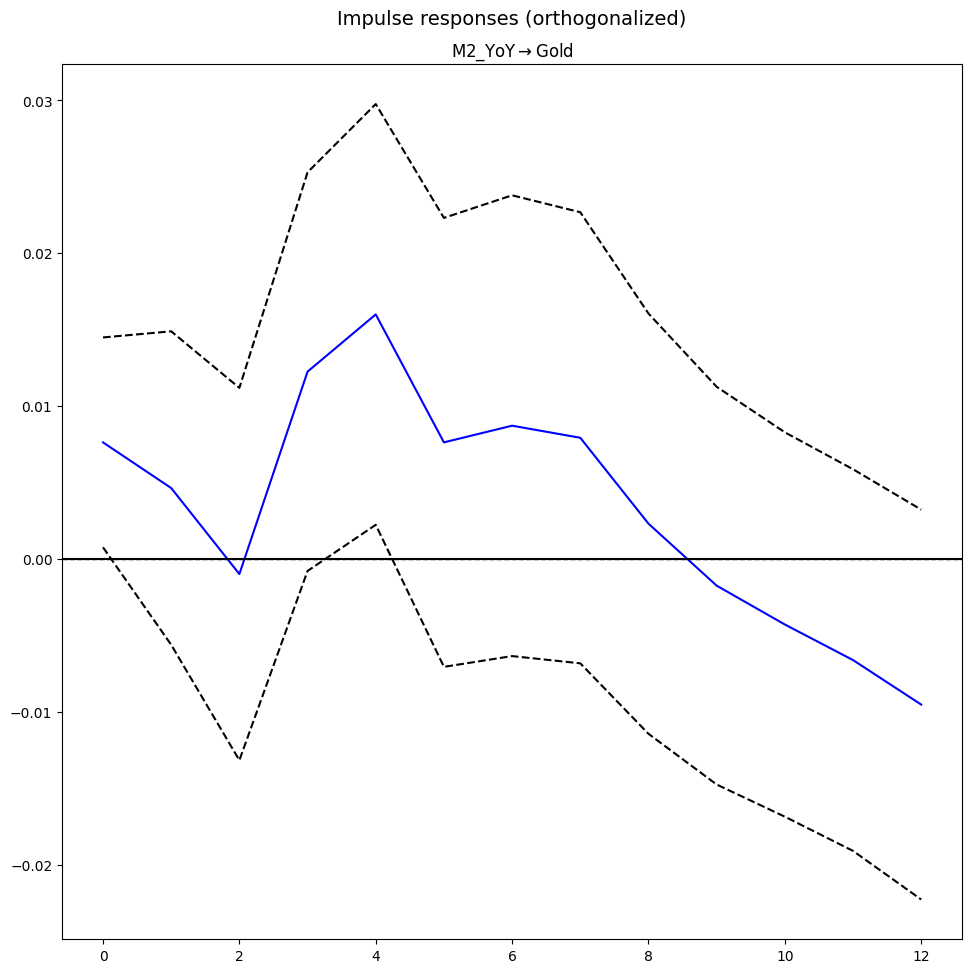

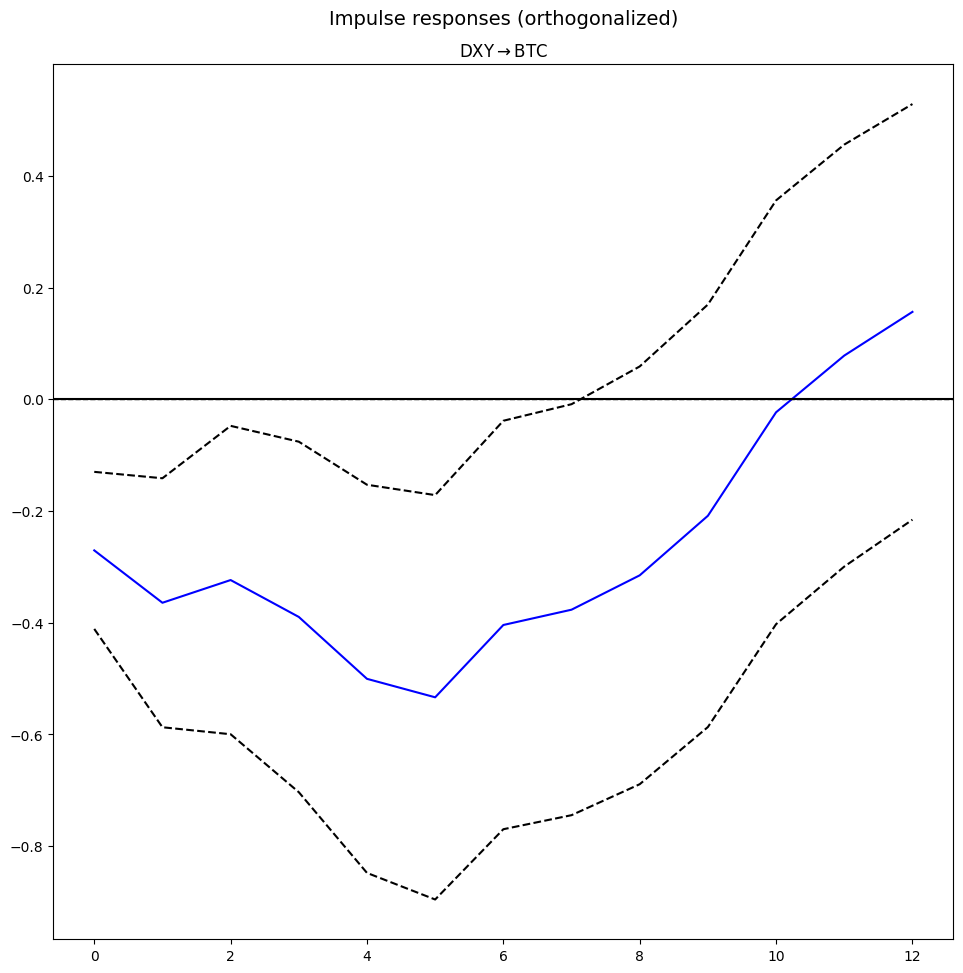

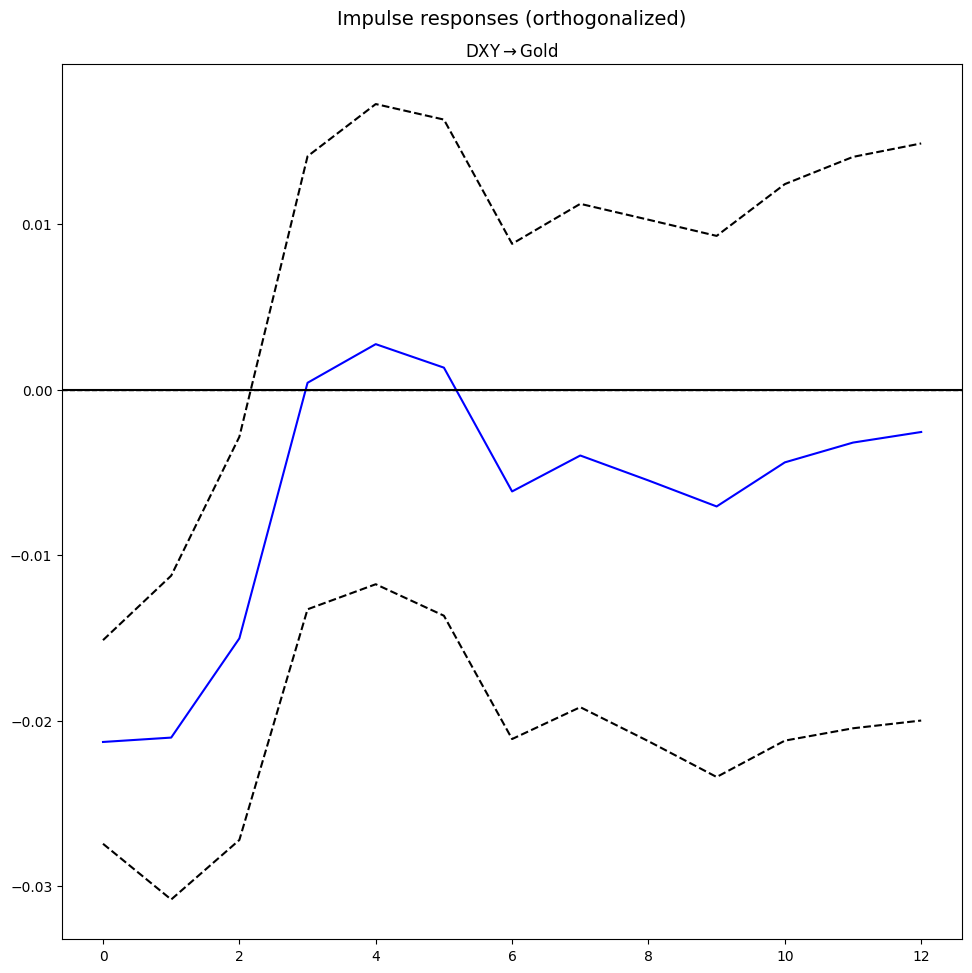

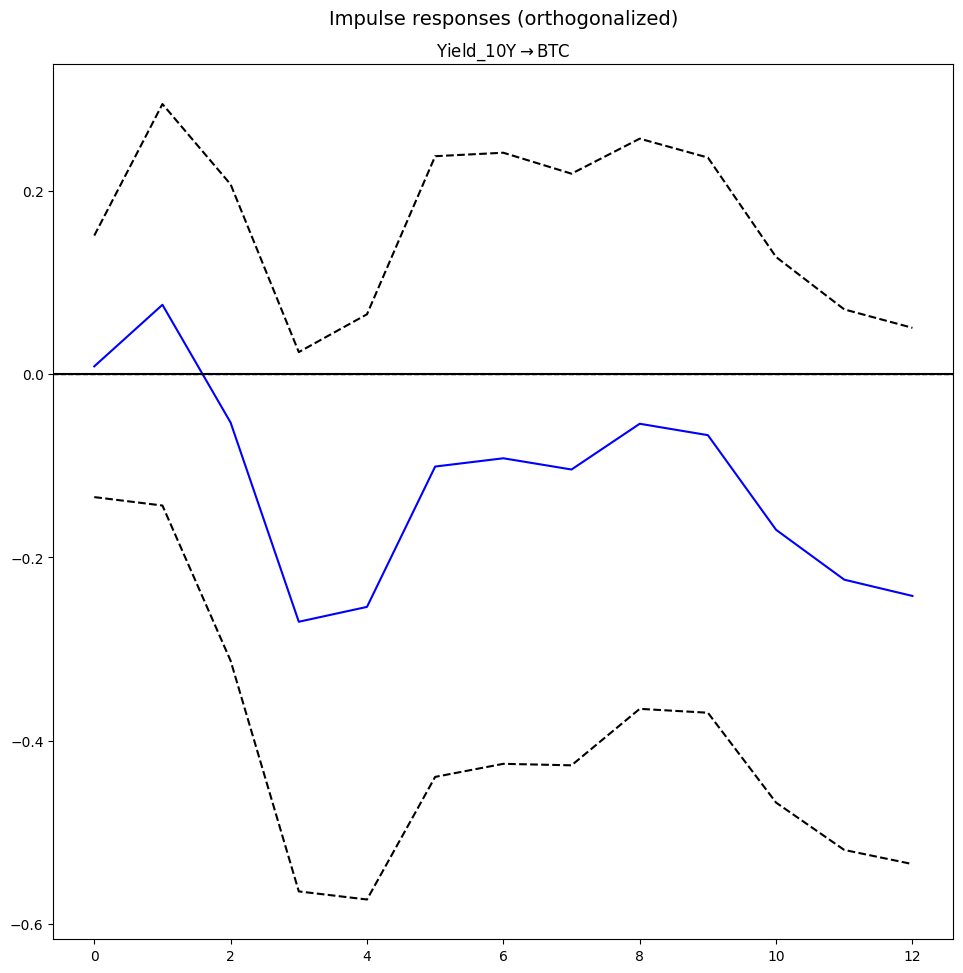

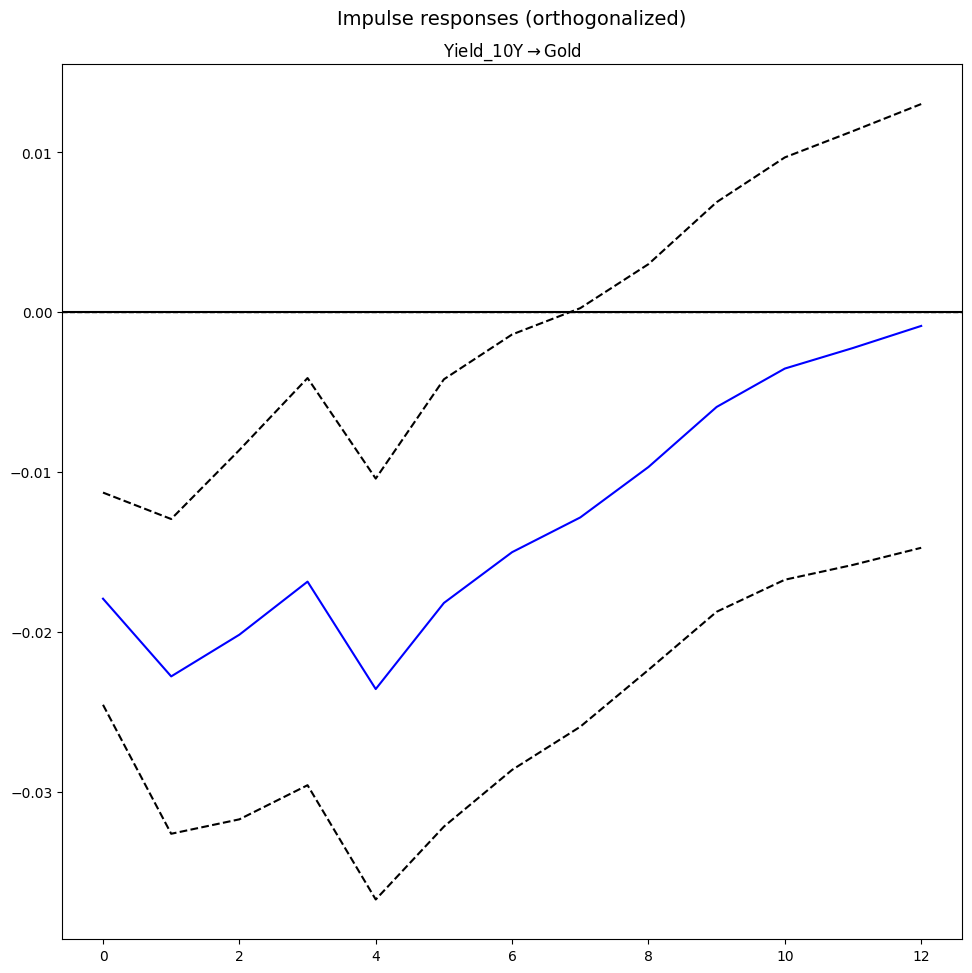

In [14]:
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR

# Setup Columns and Fit Model
cols = ['M2_YoY', 'Yield_10Y', 'DXY', 'BTC', 'Gold']
data_var = combined_monthly[cols].dropna()
model = VAR(data_var)
results = model.fit(6)
irf = results.irf(12)

# Plot 1: M2 -> BTC
fig_a = irf.plot(impulse='M2_YoY', response='BTC', orth=True, signif=0.20)
plt.axhline(0, color='black', lw=1, ls='--')

# Plot 2: M2 -> Gold
fig_b = irf.plot(impulse='M2_YoY', response='Gold', orth=True, signif=0.20)
plt.axhline(0, color='black', lw=1, ls='--')

# Plot 3: DXY -> BTC
fig_c = irf.plot(impulse='DXY', response='BTC', orth=True, signif=0.20)
plt.axhline(0, color='black', lw=1, ls='--')

# Plot 4: DXY -> Gold
fig_d = irf.plot(impulse='DXY', response='Gold', orth=True, signif=0.20)
plt.axhline(0, color='black', lw=1, ls='--')

# Plot 5: Yields -> BTC
fig_d = irf.plot(impulse='Yield_10Y', response='BTC', orth=True, signif=0.20)
plt.axhline(0, color='black', lw=1, ls='--')

# Plot 6: Yields -> Gold
fig_d = irf.plot(impulse='Yield_10Y', response='Gold', orth=True, signif=0.20)
plt.axhline(0, color='black', lw=1, ls='--')

plt.show()

FEVD for M2_YoY
        M2_YoY  Yield_10Y       DXY       BTC      Gold
0     1.000000   0.000000  0.000000  0.000000  0.000000
1     0.962745   0.021381  0.002263  0.012439  0.001172
2     0.857953   0.100090  0.014000  0.026060  0.001896
3     0.755427   0.177484  0.028624  0.035162  0.003303
4     0.682021   0.228415  0.046445  0.038349  0.004770
5     0.643523   0.249372  0.058974  0.040912  0.007220
6     0.625305   0.259033  0.060310  0.044790  0.010561
7     0.616711   0.265285  0.055905  0.049199  0.012899
8     0.608357   0.273710  0.050318  0.052485  0.015129
9     0.597265   0.285462  0.046477  0.053969  0.016827
10    0.582526   0.299807  0.045311  0.053883  0.018473
11    0.565411   0.315024  0.046265  0.053062  0.020238

FEVD for Yield_10Y
        M2_YoY  Yield_10Y       DXY       BTC      Gold
0     0.163779   0.836221  0.000000  0.000000  0.000000
1     0.098264   0.880220  0.002657  0.014782  0.004077
2     0.072177   0.896303  0.001809  0.023792  0.005918
3     0.0801

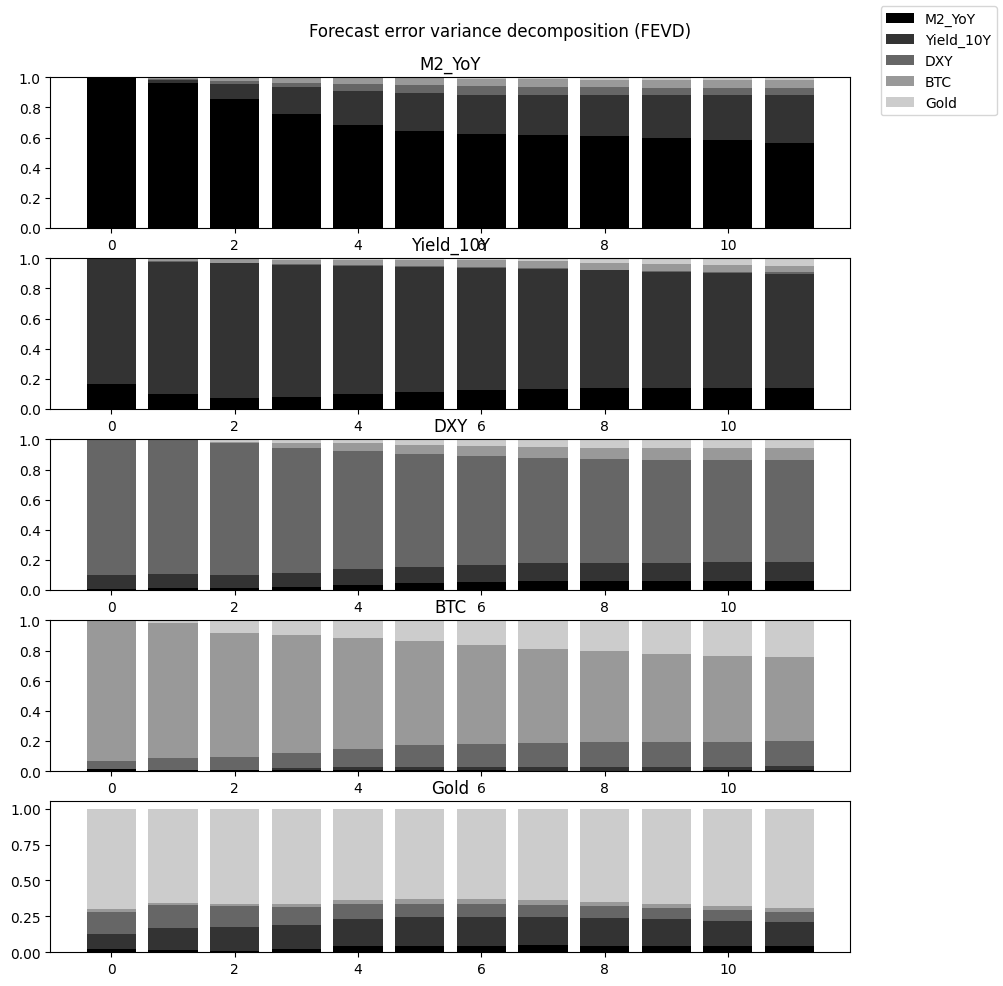

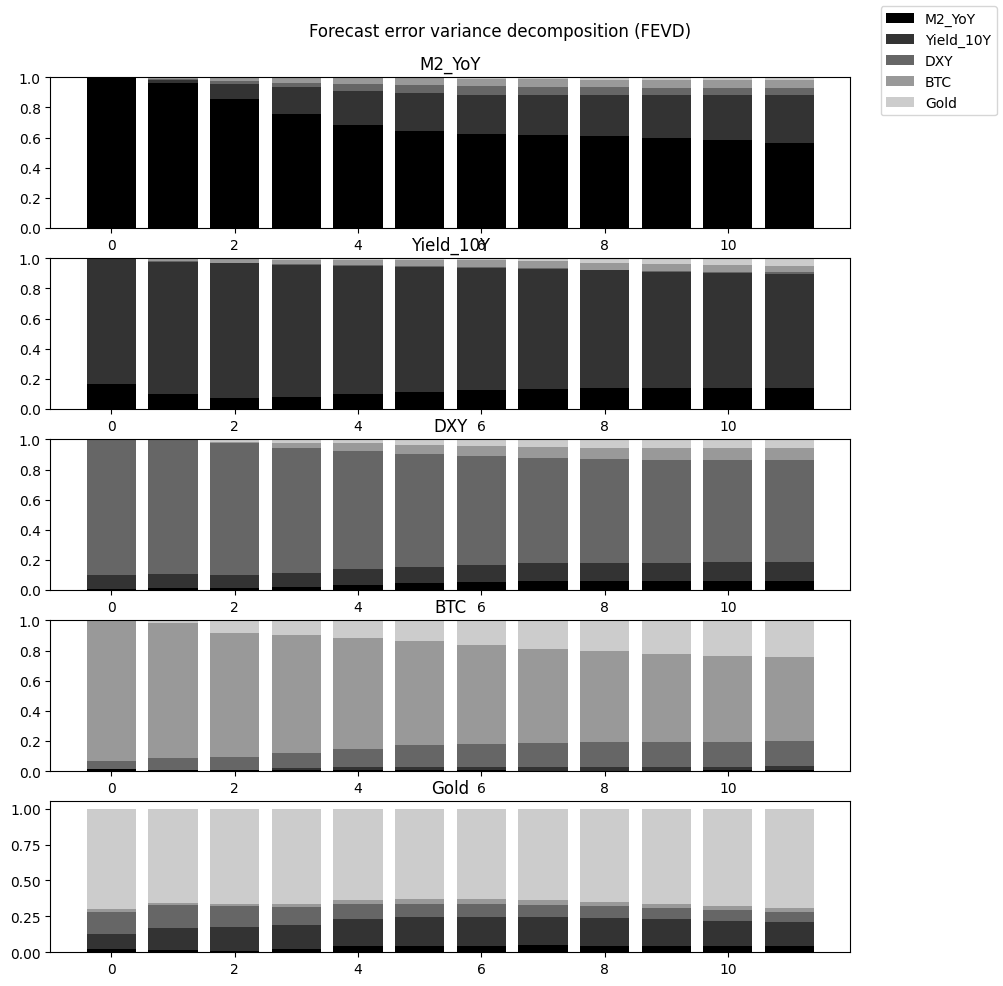

In [15]:
# Setting up FEVD for 12 Months
fevd = results.fevd(12)
print(fevd.summary()) 
fevd.plot()